# Import libraries

In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from googleapiclient.discovery import build
from transformers import pipeline
from dotenv import load_dotenv
from datetime import datetime, timezone
from dateutil.relativedelta import relativedelta
from atproto import Client
import time
from langdetect import detect, LangDetectException
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import re
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import umap

/home/andre/telecom/aibubble/ai-bubble/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Import data

In [3]:
df = pd.read_csv("bluesky_ai_posts.csv")

# TF - IDF

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

texts = df["Text"].dropna().apply(clean_text)

In [8]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.6,
    max_features=5000
)

tfidf_matrix = vectorizer.fit_transform(texts)

terms = vectorizer.get_feature_names_out()
scores = tfidf_matrix.sum(axis=0).A1

tfidf_terms_df = pd.DataFrame({
    "term": terms,
    "tfidf_score": scores
}).sort_values("tfidf_score", ascending=False)

In [12]:
tfidf_terms_df.head(60)

,term,tfidf_score
1013,chatgpt,341.024644
2510,intelligence,317.839834
523,artificial,311.869121
526,artificial intelligence,295.352471
837,bubble,281.741138
226,ai bubble,182.966710
2812,like,142.209941
2662,just,137.811830
1145,com,132.723818
3380,people,109.340740


In [6]:
tfidf_terms_df.to_csv("bsky_tfidf_terms.csv", index=False)

# Topic analysis

In [37]:
df = pd.read_csv("bluesky_ai_posts.csv")

In [38]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    df["Text"].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
)

/home/andre/telecom/aibubble/ai-bubble/venv/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
Batches: 100%|██████████| 318/318 [02:28<00:00,  2.14it/s]


In [39]:
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

reduced_embeddings = umap_model.fit_transform(embeddings)

print(reduced_embeddings.shape)

/home/andre/telecom/aibubble/ai-bubble/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(10149, 5)


In [121]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=500,
    metric="euclidean",
    prediction_data=True
)

clusters = clusterer.fit_predict(reduced_embeddings)

df["cluster"] = clusters

In [122]:
df["cluster"].value_counts()

cluster
 1    6937
 0    2143
-1    1069
Name: count, dtype: int64

In [123]:
from sklearn.feature_extraction.text import CountVectorizer

for cluster_id in sorted(df["cluster"].unique()):

    texts = df.loc[
        df["cluster"] == cluster_id,
        "Text"
    ]

    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        max_features=20
    )

    X = vectorizer.fit_transform(texts)

    frequencies = X.sum(axis=0).A1

    words = vectorizer.get_feature_names_out()

    topic_terms = sorted(
        zip(words, frequencies),
        key=lambda x: x[1],
        reverse=True
    )[:10]

    print(f"\nCluster {cluster_id}")
    print(topic_terms)


Cluster -1
[('ai', np.int64(860)), ('intelligence', np.int64(476)), ('artificial', np.int64(468)), ('artificial intelligence', np.int64(441)), ('https', np.int64(335)), ('bubble', np.int64(233)), ('com', np.int64(213)), ('openai', np.int64(185)), ('apple', np.int64(142)), ('nvidia', np.int64(134))]

Cluster 0
[('chatgpt', np.int64(2223)), ('ai', np.int64(631)), ('com', np.int64(325)), ('https', np.int64(306)), ('like', np.int64(283)), ('just', np.int64(238)), ('use', np.int64(210)), ('openai', np.int64(206)), ('using', np.int64(177)), ('www', np.int64(171))]

Cluster 1
[('ai', np.int64(6852)), ('intelligence', np.int64(2854)), ('artificial', np.int64(2799)), ('artificial intelligence', np.int64(2613)), ('bubble', np.int64(2307)), ('com', np.int64(1302)), ('https', np.int64(1133)), ('ai bubble', np.int64(1071)), ('www', np.int64(753)), ('like', np.int64(694))]


In [134]:
for cluster_id in sorted(df["cluster"].unique()):

    print(f"\n===== CLUSTER {cluster_id} =====")

    sample = df[
        df["cluster"] == cluster_id
    ]["Text"].sample(
        min(5, len(df[df["cluster"] == cluster_id])),
        random_state=42
    )

    for post in sample:
        print(post)
        print("-" * 50)


===== CLUSTER -1 =====
OpenAI Responds to DeepSeek Hype with ‘Deep Research’ ChatGPT Agent

Artificial intelligence firm OpenAI has launched Deep Research, a new AI-powered agent within ChatGPT that independently conducts in-depth web research, analyzes data, and compiles reports—completing tasks that would take humans…
--------------------------------------------------
[CNBC]Nvidia is worth nearly $1 trillion—here’s how much you’d have if you invested a decade ago - CNBC Nvidia, whose computer chips power AI tools such as ChatGPT, is worth almost $1 trillion. What you'd have if you invested $1,000 one, five, and 10 years ago.
--------------------------------------------------
Apple’s Foundational Models Lead Joins Meta: Report Meta’s hiring spree continues. The post Apple’s Foundational Models Lead Joins Meta: Report appeared first on Analytics India Magazine . ...

#AI #News #AI #(Artificial #Intelligence) #Meta

Origin | Interest | Match
--------------------------------------------

# Plot by time

## Financial data

In [125]:
import yfinance as yf
import pandas as pd

stock = "AIQ"  # Replace with your desired stock ticker

market = yf.download(
    stock,
    start="2022-01-01",
    end="2025-12-31",
    interval="1d"
)

[*********************100%***********************]  1 of 1 completed


In [127]:
market_df = market.copy()

market_df.columns = market_df.columns.get_level_values(0)

market_df = market_df.reset_index()

date_col = market_df.columns[0]

market_df = (
    market_df[[date_col, "Close"]]
    .rename(columns={
        date_col: "Date",
        "Close": "Value"
    })
)

market_df.head()

Price,Date,Value
0,2022-01-03,31.551304
1,2022-01-04,31.056618
2,2022-01-05,29.988085
3,2022-01-06,29.978191
4,2022-01-07,29.859468


## Aggregate on average

In [128]:
# df = pd.read_csv("bluesky_ai_posts_with_clusters.csv")

In [129]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# Prepare cluster data
# --------------------------------------------------

WINDOW_SIZE = 60

df["Date"] = pd.to_datetime(
    df["Date"],
    format="mixed",
    utc=True
)

daily_clusters = (
    df
    .groupby([
        pd.Grouper(key="Date", freq="D"),
        "cluster"
    ])
    .size()
    .unstack(fill_value=0)
)

# 15-day rolling average
cluster_smooth = (
    daily_clusters
    .rolling(window=WINDOW_SIZE, center=True, min_periods=1)
    .mean()
)

cluster_norm = cluster_smooth.copy()

for col in cluster_norm.columns:

    min_val = cluster_norm[col].min()
    max_val = cluster_norm[col].max()

    cluster_norm[col] = (
        (cluster_norm[col] - min_val)
        /
        (max_val - min_val)
    ) * 100


In [130]:
# --------------------------------------------------
# Prepare market index
# --------------------------------------------------

market_df["Date"] = pd.to_datetime(market_df["Date"])

market_df = (
    market_df
    .sort_values("Date")
    .set_index("Date")
)

# Resample to daily frequency
market_daily = market_df["Value"].resample("D").ffill()

# 15-day rolling average
market_smooth = (
    market_daily
    .rolling(window=WINDOW_SIZE, center=True, min_periods=1)
    .mean()
)

market_norm = (
    (market_smooth - market_smooth.min())
    /
    (market_smooth.max() - market_smooth.min())
) * 100


# Plot

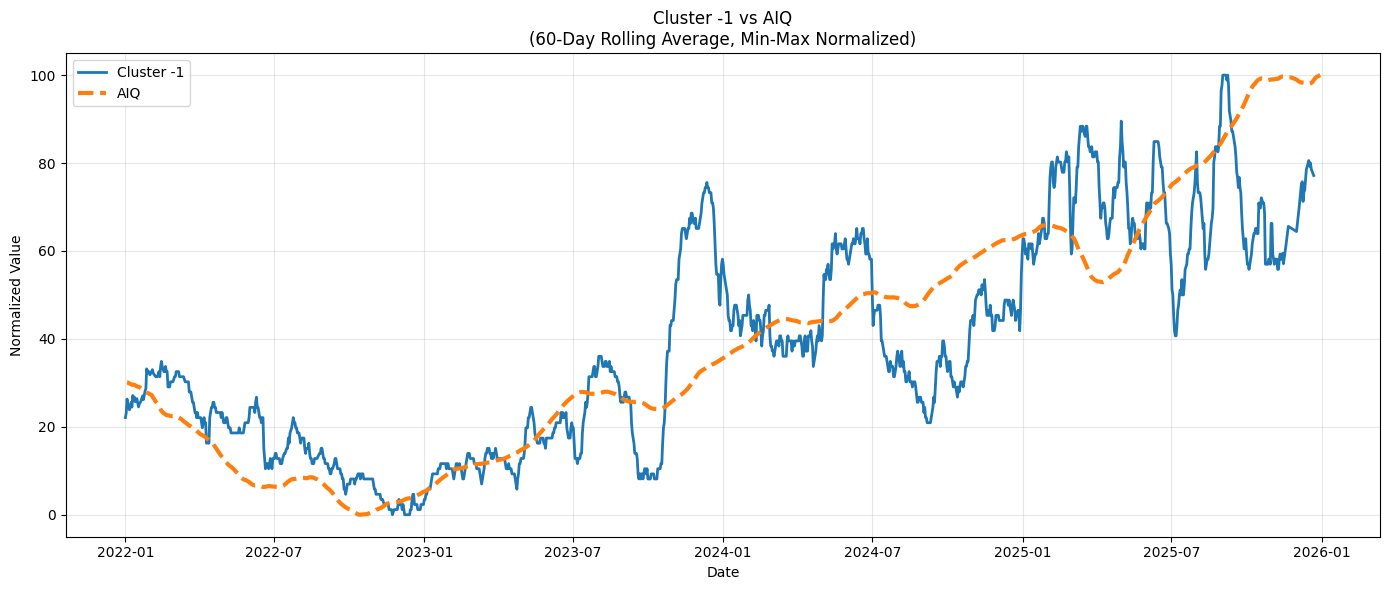

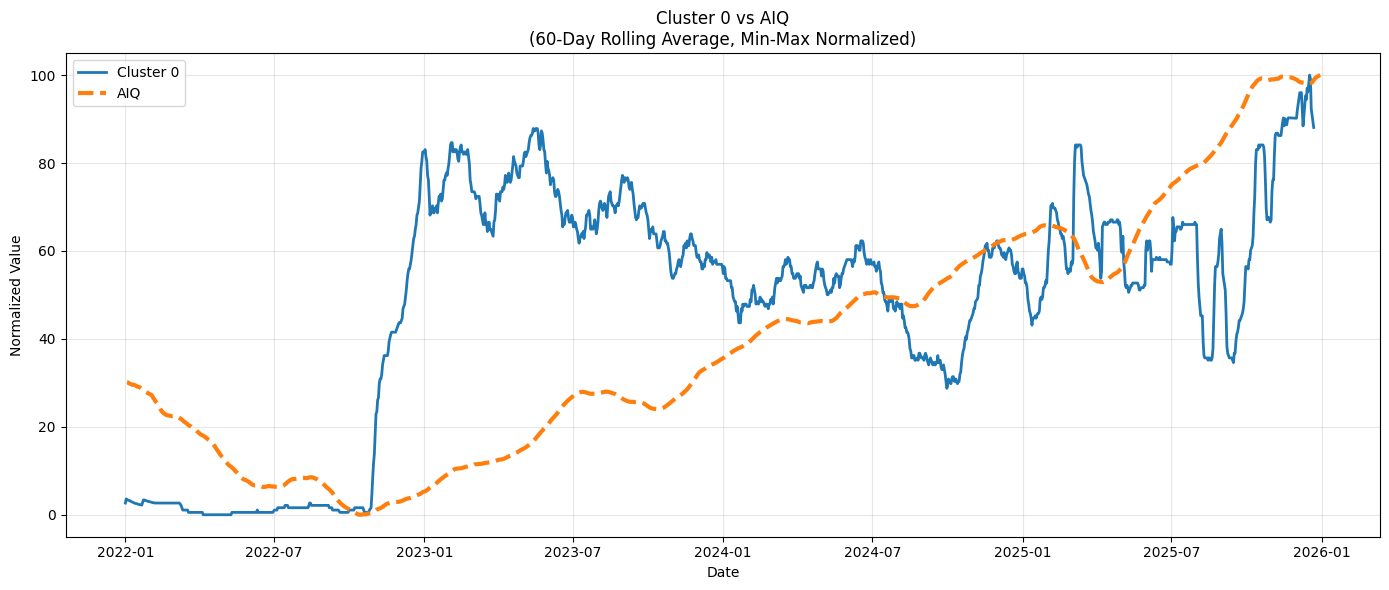

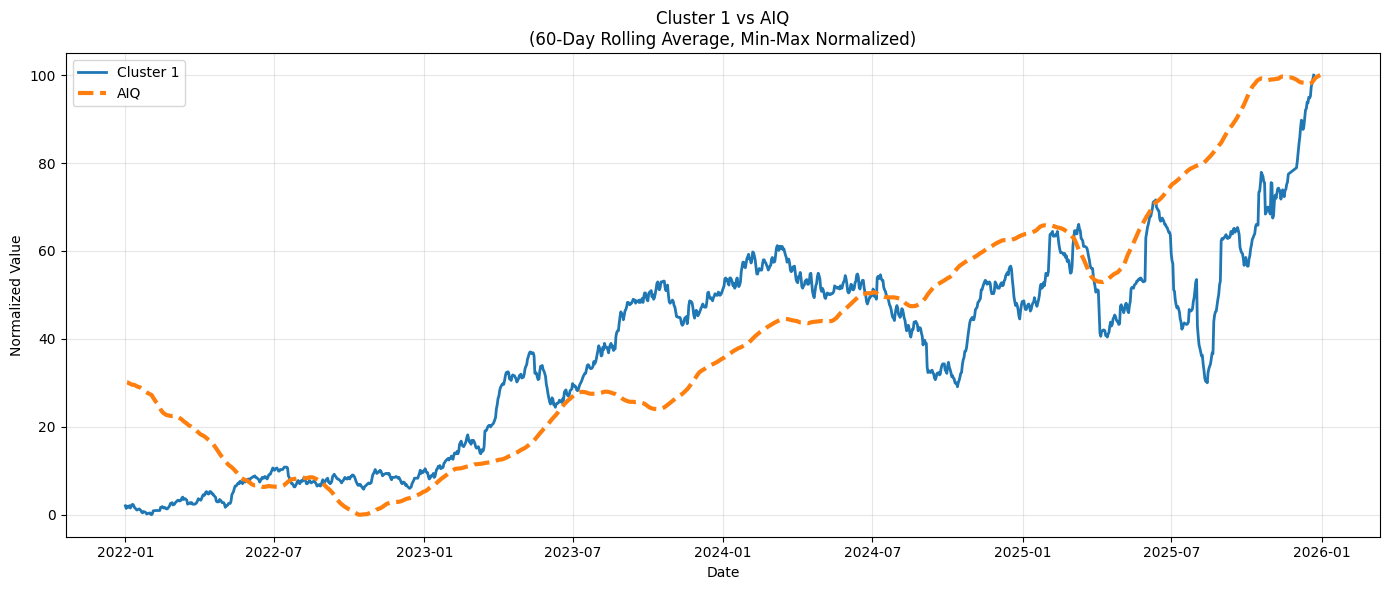

In [131]:
# --------------------------------------------------
# Plot
# --------------------------------------------------

import matplotlib.pyplot as plt

for cluster in cluster_norm.columns:

    plt.figure(figsize=(14,6))

    plt.plot(
        cluster_norm.index,
        cluster_norm[cluster],
        linewidth=2,
        label=f"Cluster {cluster}"
    )

    plt.plot(
        market_norm.index,
        market_norm.values,
        linestyle="--",
        linewidth=3,
        label=f"{stock}"
    )

    plt.title(
        f"Cluster {cluster} vs {stock}\n"
        f"({WINDOW_SIZE}-Day Rolling Average, Min-Max Normalized)"
    )

    plt.ylabel("Normalized Value")
    plt.xlabel("Date")

    plt.grid(alpha=0.3)
    plt.legend()

    # plt.savefig(
    # f"plots/cluster_{cluster}_vs_{stock}.png",
    # dpi=300,
    # bbox_inches="tight")

    plt.tight_layout()
    plt.show()


In [132]:
# Make both indexes timezone-naive
cluster_norm.index = pd.to_datetime(cluster_norm.index).tz_localize(None)
market_norm.index = pd.to_datetime(market_norm.index).tz_localize(None)

print(f"\nCorrelation between clusters and market index: {stock}\n")
for cluster in cluster_norm.columns:

    combined = pd.concat(
        [
            cluster_norm[cluster].rename("cluster"),
            market_norm.rename("market")
        ],
        axis=1
    ).dropna()

    corr = combined.corr().iloc[0, 1]

    print(f"Cluster {cluster}: correlation = {corr:.3f}")


Correlation between clusters and market index: AIQ

Cluster -1: correlation = 0.821
Cluster 0: correlation = 0.383
Cluster 1: correlation = 0.812


/tmp/ipykernel_32438/1931310235.py:8: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat(
/tmp/ipykernel_32438/1931310235.py:8: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat(
/tmp/ipykernel_32438/1931310235.py:8: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not

In [136]:
# Get posts with higher weight for each cluster

for cluster_id in sorted(df["cluster"].unique()):
    
    cluster_posts = df[df["cluster"] == cluster_id]

    if len(cluster_posts) == 0:
        continue

    top_posts = cluster_posts.sort_values("Weight", ascending=False).head(5)

    print(f"\n===== CLUSTER {cluster_id} - TOP POSTS =====")

    for idx, row in top_posts.iterrows():
        print(f"Weight: {row['Weight']:.4f} - Date: {row['Date']} - Text: {row['Text']}")
        print("-" * 80)


===== CLUSTER -1 - TOP POSTS =====
Weight: 813.0000 - Date: 2025-04-28 17:11:38.325000+00:00 - Text: It's blatantly obvious that generative AI is a bubble. The returns and products just aren't there, and yet the media compliantly prints whatever OpenAI wants, even when it's insane things such as "they'll make $3bn from an agent product that barely exists in 2025."
www.wheresyoured.at/reality-check/
--------------------------------------------------------------------------------
Weight: 760.0000 - Date: 2024-11-27 21:31:01.004000+00:00 - Text: BREAKING: The US Federal Trade Commission has opened an antitrust investigation of Microsoft, $MSFT, drilling into everything from the company’s cloud computing and software licensing businesses to cybersecurity offerings and artificial intelligence products.
--------------------------------------------------------------------------------
Weight: 589.0000 - Date: 2025-08-19 22:39:51.028000+00:00 - Text: Students don’t need chromebooks and AI tuto

In [133]:
#save dataset with cluster labels and dates
# df.to_csv("bluesky_ai_posts_with_1_clusters.csv", index=False)